# Low-Resolution Agricultural Land Classification Using CNN and CNN–Transformer Hybrid

## Objective


• Build a complete image classification pipeline from raw satellite data to evaluation

• Understand how convolutional neural networks extract local spatial features from low-resolution imagery

• Implement and train a baseline CNN for binary agricultural land classification

• Integrate a Transformer encoder on top of a trained CNN backbone to model global spatial relationships

• Compare CNN and CNN–Transformer hybrid architectures under identical data conditions

• Evaluate models using confusion matrix, precision, recall, F1-score, and accuracy

• Analyze whether adding attention mechanisms provides measurable benefit on a low-complexity dataset

• Develop architectural intuition about model capacity versus dataset difficulty

• Identify when hybrid deep learning architectures are justified and when simpler models are sufficient


## Data

### Download Data and extract TAR dataset

In [7]:
import os
import requests
import tarfile
from tqdm import tqdm

DATA_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/4Z1fwRR295-1O3PMQBH6Dg/images-dataSAT.tar"
DATA_DIR = "data"
TAR_PATH = "dataset.tar"

def download_file(url, save_path):
    response = requests.get(url, stream=True)
    total_size = int(response.headers.get('content-length', 0))

    with open(save_path, 'wb') as file, tqdm(
        desc="Downloading",
        total=total_size,
        unit='iB',
        unit_scale=True,
    ) as bar:
        for chunk in response.iter_content(chunk_size=1024):
            file.write(chunk)
            bar.update(len(chunk))

def extract_tar(tar_path, extract_to):
    with tarfile.open(tar_path, "r") as tar:
        tar.extractall(path=extract_to)

if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR)

if not os.path.exists(TAR_PATH):
    download_file(DATA_URL, TAR_PATH)

print("Extracting...")
extract_tar(TAR_PATH, DATA_DIR)

print("Done.")

Downloading: 100%|██████████| 20.2M/20.2M [00:00<00:00, 30.9MiB/s]
/tmp/ipython-input-3473179849.py:26: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_to)


Extracting...
Done.


In [16]:
# Verify structure

for root, dirs, files in os.walk(DATA_DIR):
    print(root)
    break

data


In [14]:
DATASET_PATH = os.path.join(DATA_DIR, "images_dataSAT")

### Data Loading and Augmentation

In [15]:
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATASET_PATH = os.path.join(DATA_DIR, "images_dataSAT")

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

dataset = datasets.ImageFolder(root=DATASET_PATH, transform=train_transform)

print("Classes:", dataset.classes)
print("Total Images:", len(dataset))

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

val_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

Classes: ['class_0_non_agri', 'class_1_agri']
Total Images: 6000


In [21]:
num_classes = len(dataset.classes)
print(dataset.classes)
print("Number of classes:", num_classes)

['class_0_non_agri', 'class_1_agri']
Number of classes: 2


###Checking Data Pipeline

In [17]:
images, labels = next(iter(train_loader))
print(images.shape)   # should be [batch, 3, 64, 64]
print(labels.shape)
print(labels[:10])

torch.Size([32, 3, 64, 64])
torch.Size([32])
tensor([1, 1, 0, 1, 0, 0, 1, 1, 1, 0])


* Matches the requirements.

### Images

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import torch

In [35]:
# Unnormalize function

def unnormalize(img):
    img = img * 0.5 + 0.5
    return img

In [36]:
# Function to display images

def show_samples_per_class(dataset, class_names, samples_per_class=2):
    plt.figure(figsize=(8, 4))

    class_counts = {i: 0 for i in range(len(class_names))}
    img_index = 1

    for img, label in dataset:
        if class_counts[label] < samples_per_class:
            plt.subplot(len(class_names), samples_per_class, img_index)

            img = unnormalize(img)
            img = img.permute(1, 2, 0).numpy()

            plt.imshow(img)
            plt.title(class_names[label])
            plt.axis("off")

            class_counts[label] += 1
            img_index += 1

        if all(count == samples_per_class for count in class_counts.values()):
            break

    plt.tight_layout()
    plt.show()

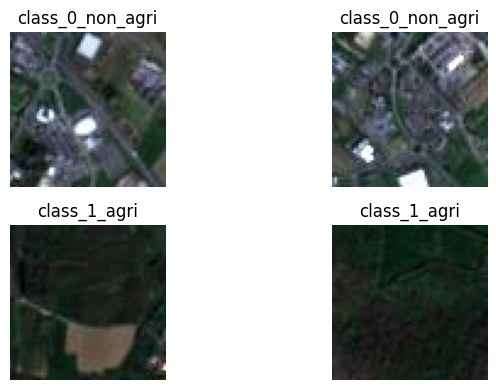

In [37]:
# Images

show_samples_per_class(dataset, dataset.classes, samples_per_class=2)

## CNN

### Baseline CNN

In [18]:
import torch.nn as nn

class CNNBackbone(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

    def forward(self, x):
        return self.features(x)


class CNNClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = CNNBackbone()
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

### Train and Validation Loop with accuracy

In [19]:
import torch.optim as optim

def train_model(model, train_loader, val_loader, epochs=10):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(epochs):

        # ---- TRAIN ----
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = correct / total

        # ---- VALIDATION ----
        model.eval()
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_acc = val_correct / val_total

        print(f"Epoch {epoch+1} | Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")

    return model

### Training the CNN model

In [22]:
cnn_model = CNNClassifier(num_classes)
cnn_model = train_model(cnn_model, train_loader, val_loader, epochs=10)

Epoch 1 | Train Acc: 0.980 | Val Acc: 0.998
Epoch 2 | Train Acc: 0.990 | Val Acc: 0.993
Epoch 3 | Train Acc: 0.990 | Val Acc: 0.989
Epoch 4 | Train Acc: 0.989 | Val Acc: 0.984
Epoch 5 | Train Acc: 0.992 | Val Acc: 0.995
Epoch 6 | Train Acc: 0.993 | Val Acc: 1.000
Epoch 7 | Train Acc: 0.993 | Val Acc: 0.998
Epoch 8 | Train Acc: 0.992 | Val Acc: 0.998
Epoch 9 | Train Acc: 0.993 | Val Acc: 0.999
Epoch 10 | Train Acc: 0.994 | Val Acc: 0.997


In [24]:
# save the model

torch.save(cnn_model.backbone.state_dict(), "cnn_backbone.pth")

## Hybrid Model

In [25]:
class HybridCNNViT(nn.Module):
    def __init__(self, backbone, num_classes):
        super().__init__()

        self.backbone = backbone

        for param in self.backbone.parameters():
            param.requires_grad = False

        self.flatten = nn.Flatten(2)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=128,
            nhead=4,
            dim_feedforward=256,
            dropout=0.1,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=4
        )

        self.cls_token = nn.Parameter(torch.randn(1,1,128))
        self.pos_embed = nn.Parameter(torch.randn(1,65,128))

        self.head = nn.Sequential(
            nn.LayerNorm(128),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)          # (B,128,8,8)
        x = self.flatten(x)           # (B,128,64)
        x = x.transpose(1,2)          # (B,64,128)

        B = x.size(0)

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        x = x + self.pos_embed[:, :x.size(1), :]

        x = self.transformer(x)

        cls_output = x[:,0]
        return self.head(cls_output)

### Train Hybrid (Stage 1: Frozen CNN)

In [26]:
hybrid_model = HybridCNNViT(
    backbone=cnn_model.backbone,
    num_classes=num_classes
)

def train_hybrid(model, train_loader, val_loader, epochs=10):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=5e-4
    )

    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_acc = correct / total

        model.eval()
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (preds == labels).sum().item()

        val_acc = val_correct / val_total

        print(f"Epoch {epoch+1} | Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")

    return model

hybrid_model = train_hybrid(hybrid_model, train_loader, val_loader, epochs=10)

Epoch 1 | Train Acc: 0.990 | Val Acc: 0.998
Epoch 2 | Train Acc: 0.991 | Val Acc: 0.996
Epoch 3 | Train Acc: 0.991 | Val Acc: 0.999
Epoch 4 | Train Acc: 0.993 | Val Acc: 1.000
Epoch 5 | Train Acc: 0.994 | Val Acc: 1.000
Epoch 6 | Train Acc: 0.994 | Val Acc: 0.998
Epoch 7 | Train Acc: 0.993 | Val Acc: 0.996
Epoch 8 | Train Acc: 0.996 | Val Acc: 0.999
Epoch 9 | Train Acc: 0.994 | Val Acc: 0.999
Epoch 10 | Train Acc: 0.996 | Val Acc: 0.998


## Model Comparison

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [28]:
# Function to get predictions

def get_predictions(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)

In [29]:
# Plotting confusion matrix

def plot_conf_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure()
    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names)
    plt.yticks(tick_marks, class_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j],
                     horizontalalignment="center")

    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()

### CNN Confusion Matrix



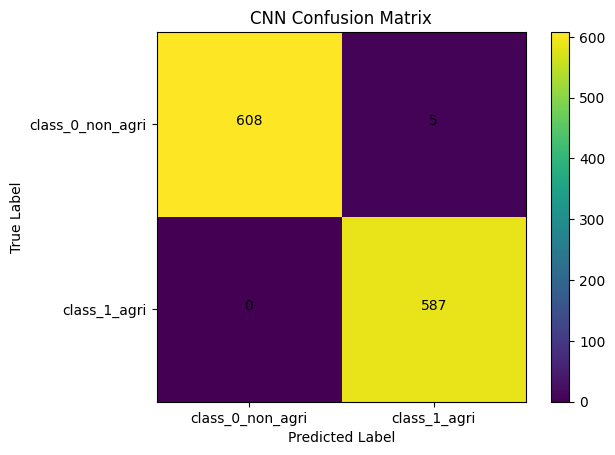

In [30]:
y_true_cnn, y_pred_cnn = get_predictions(cnn_model, val_loader)

plot_conf_matrix(
    y_true_cnn,
    y_pred_cnn,
    dataset.classes,
    "CNN Confusion Matrix"
)

### Hybrid Model Confusion Matrix


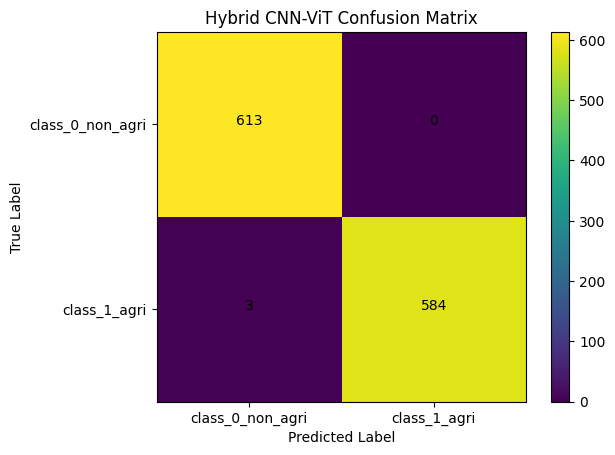

In [31]:
y_true_hybrid, y_pred_hybrid = get_predictions(hybrid_model, val_loader)

plot_conf_matrix(
    y_true_hybrid,
    y_pred_hybrid,
    dataset.classes,
    "Hybrid CNN-ViT Confusion Matrix"
)

### Evaluation of Models


#### CNN

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

def evaluate_model(model, val_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    print("Confusion Matrix:")
    print(confusion_matrix(all_labels, all_preds))

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=dataset.classes))

evaluate_model(cnn_model, val_loader)

Confusion Matrix:
[[609   4]
 [  0 587]]

Classification Report:
                  precision    recall  f1-score   support

class_0_non_agri       1.00      0.99      1.00       613
    class_1_agri       0.99      1.00      1.00       587

        accuracy                           1.00      1200
       macro avg       1.00      1.00      1.00      1200
    weighted avg       1.00      1.00      1.00      1200



#### Hybrid CNN-ViT

In [33]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

def evaluate_model(model, val_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    print("Confusion Matrix:")
    print(confusion_matrix(all_labels, all_preds))

    print("\nClassification Report:")
    print(classification_report(
        all_labels,
        all_preds,
        target_names=dataset.classes
    ))

# Evaluate Hybrid
evaluate_model(hybrid_model, val_loader)

Confusion Matrix:
[[613   0]
 [  3 584]]

Classification Report:
                  precision    recall  f1-score   support

class_0_non_agri       1.00      1.00      1.00       613
    class_1_agri       1.00      0.99      1.00       587

        accuracy                           1.00      1200
       macro avg       1.00      1.00      1.00      1200
    weighted avg       1.00      1.00      1.00      1200



# Insights

• Validation set is balanced. 613 non_agri, 587 agri. No class imbalance bias.

• CNN made 4 total errors out of 1200. Error rate ≈ 0.33 percent.

• Hybrid made 3 total errors out of 1200. Error rate ≈ 0.25 percent.

• Difference between CNN and Hybrid is 1 sample. This is statistically insignificant.

• CNN recall for agri is 100 percent. It did not miss a single agri sample.

• Hybrid recall for non_agri is 100 percent. It did not miss a single non_agri sample.

• CNN slightly over-predicts agri when uncertain. Hybrid slightly over-predicts non_agri.

• Precision, recall, and F1 are all effectively 1.00. Both models are near perfect.

• CNN alone is already sufficient to separate features in this dataset.

• Transformer adds almost no measurable improvement. Global attention is not contributing meaningful new signal.

• Dataset is likely low complexity. Clear texture or color differences between classes.

• This is a capacity mismatch. Model power exceeds dataset difficulty.

• Hybrid architecture is educational here, not performance-driven.

• If deployed, CNN is preferable. Simpler, fewer parameters, faster inference.

• To justify hybrid, you need harder conditions: fewer samples, higher resolution, more classes, domain shift, or noisy labels.